<a href="https://colab.research.google.com/github/aibasit/breast-cancer-diagnosis-tensorflow/blob/main/breast_cancer_prediction_tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ML For Embedded Systems**

##Dated: 15 Apr 2026

- I got this code running on my local system with the following settings:
Python 3.9.6

- I have also created the requirements.txt file for you if you want to install it on your own system.
- Best will be to run it on google Colab that should have everything pre-installed

# **Your Name: Abdul Basit**

In today's quiz I am giving you some skeleton code for classification of UCI ML Breast Cancer Wisconsin (Diagnostic) datasets. https://goo.gl/U2Uwz2. You are free to use any of these tools for completing the tasks


*   Chat GPT
*   Gemini





1.   Task 1: Add the pre-requisite libraries
2.   List item



# Task 1: Add the pre-requisite libraries (01 Marks)


In [ ]:
# Over here we add the pre-requisite libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"

labels = ["ID", "Diagnosis",
          "radius (mean)", "texture (mean)", "perimeter (mean)", "area (mean)",
          "smoothness (mean)", "compactness (mean)", "concavity (mean)",
          "concave points (mean)", "symmetry (mean)", "fractal dimension (mean)",
          "radius (error)", "texture (error)", "perimeter (error)", "area (error)",
          "smoothness (error)", "compactness (error)", "concavity (error)",
          "concave points (error)", "symmetry (error)", "fractal dimension (error)",
          "radius (worst)", "texture (worst)", "perimeter (worst)", "area (worst)",
          "smoothness (worst)", "compactness (worst)", "concavity (worst)",
          "concave points (worst)", "symmetry (worst)", "fractal dimension (worst)"]

df = pd.read_csv(url, names=labels)
df.shape

(569, 32)

In [ ]:
# Load Data
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"
labels = ["ID", "Diagnosis",
          "radius (mean)", "texture (mean)", "perimeter (mean)", "area (mean)",
          "smoothness (mean)", "compactness (mean)", "concavity (mean)",
          "concave points (mean)","symmetry (mean)", "fractal dimension (mean)",
          "radius (error)", "texture (error)", "perimeter (error)", "area (error)",
          "smoothness (error)", "compactness (error)", "concavity (error)",
          "concave points (error)","symmetry (error)", "fractal dimension (error)",
          "radius (worst)", "texture (worst)", "perimeter (worst)", "area (worst)",
          "smoothness (worst)", "compactness (worst)", "concavity (worst)",
          "concave points (worst)","symmetry (worst)", "fractal dimension (worst)"]

In [ ]:
# Reading the CSV File and displaying the shape of the read data
df = pd.read_csv(url, names=labels)
df.shape

NameError: name 'pd' is not defined

In [ ]:
# Count how many are Benign and Malignant
# this shows wha tis the distribution of the data
df.Diagnosis.value_counts()

,count
Diagnosis,
B,357
M,212


Is the data balanced?

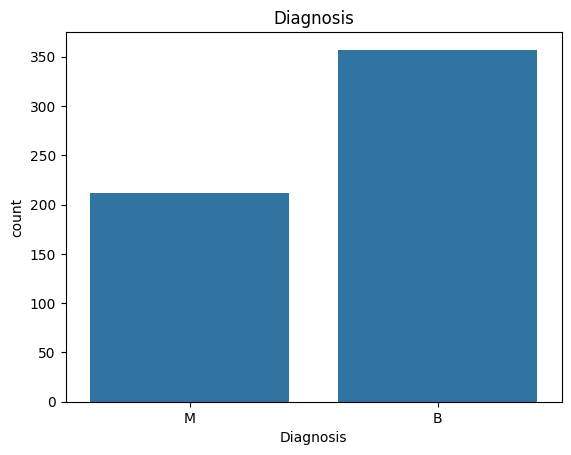

In [ ]:
sns.countplot(x='Diagnosis', data=df)
plt.title("Diagnosis")
plt.show()

**Answer:**

The Dataset is not perfectly balanced. It need to be balanced properly.*italicized text*

## Preprocessing the data

In this section you have to noramalise the traninig and test data between 0-1

Converting the data labels into numeric

In [ ]:
df["Diagnosis"] = df.Diagnosis.map(dict(M=1, B=0))

In [ ]:
df.Diagnosis.value_counts()

,count
Diagnosis,
0,357
1,212


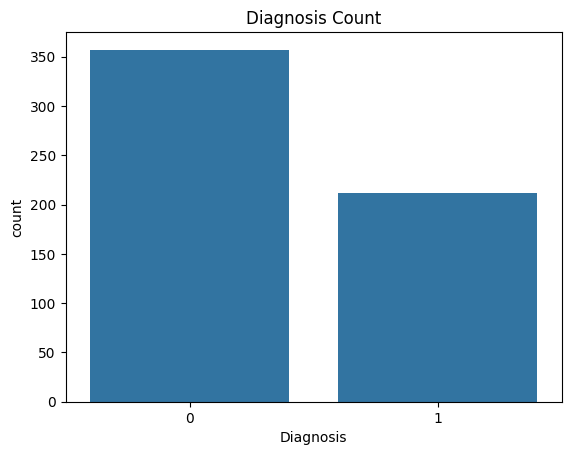

In [ ]:
sns.countplot(x='Diagnosis', data=df)
plt.title("Diagnosis Count")
plt.show()

In [ ]:
df["Diagnosis"] = df["Diagnosis"].map({"M": 1, "B": 0})
df["Diagnosis"].value_counts()

,count
Diagnosis,


Converting Pandas Dataframe to numpy

In [ ]:
X = df.drop('Diagnosis',axis=1).values
y = df['Diagnosis'].values
X.shape, y.shape

((569, 31), (569,))

# Task2: Splitting Data into training and test -- (01 Marks)

Here we are going to use the 25% of the data for the testing purposes.

We can use the sklearn.model_selection for the specific functions

In [ ]:

from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = # YOUR FUNCTION GOES HERE

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

Displaying the size of training and test data

In [ ]:
X_train.shape, X_test.shape

((426, 31), (143, 31))

Task : Normalising the data between 0-1

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

scaler.fit(X_train)

MinMaxScaler()

In [ ]:
# Normalising the data
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

Displaying the minimum and maximum values in the training data

In [ ]:
X_train.min(), X_train.max()

(np.float64(0.0), np.float64(1.0))

In [ ]:
X_test.min(), X_test.max()

(np.float64(-0.057127602776294695), np.float64(1.3264399566986453))

Can you try to explain why TEST data is not exactly between 0 and 1

#### **Answer:**

Answer:

**X_train** is exactly between 0 and 1 because the scaler is fit on training data.


**X_test** may not be exactly between 0 and 1 because some test values can be smaller than the training minimum or larger than the training maximum.

**02 marks**

## Creating Model

Over here, we are going to create a dense NN using tensorflow. here is the definition of the network.


*   30x neurons in the input layer
*   15x neurons in the hidden layer
*   1x neurons in the output layer



Q: Why are we using 30 and 1 neurons in the input and output layers, respectively?

**02 Marks**

In [ ]:
import tensorflow as tf

In [ ]:
input_shape = X.shape[1]
X.shape

(569, 31)

# Task 3: Complete the following details for the model to compile -- 02 Marks

In [ ]:
LAYER_ACTIVATION =      # Enter your answer
LAST_LAYER_ACTIVATION = # Enter your answer
INPUT_LAYER_NEURON =    # Enter the no of neuron in the input layer
OUTPUT_LAYER_NEURONS =  # Enter the no of neuron in the input layer
LOSS =                  # Enter your answer
OPT =                   # Enter your answer

In [ ]:
LAYER_ACTIVATION = 'relu'
LAST_LAYER_ACTIVATION = 'sigmoid'
INPUT_LAYER_NEURON = 30
OUTPUT_LAYER_NEURONS = 1
LOSS = 'binary_crossentropy'
OPT = 'adam'

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(units=INPUT_LAYER_NEURON,
                          activation=LAYER_ACTIVATION,
                          input_shape=[input_shape]),
    tf.keras.layers.Dense(units=15, activation=LAYER_ACTIVATION),
    tf.keras.layers.Dense(units=OUTPUT_LAYER_NEURONS,
                          activation=LAST_LAYER_ACTIVATION)
])

model.compile(
    loss=LOSS,
    optimizer=OPT,
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 30)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 15)             │           465 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,441 (5.63 KB)

 Trainable params: 1,441 (5.63 KB)

 Non-trainable params: 0 (0.00 B)

## Training the model

Running the model training for 600 Epochs. By the end I am getting an follwing:
- loss: 0.0129 - accuracy: 0.9977
- val_loss: 0.3260 - val_accuracy: 0.9650

In [ ]:
history = model.fit(      #Testing on 20 Epochs first
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.6103 - loss: 0.6721 - val_accuracy: 0.7622 - val_loss: 0.6472
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8146 - loss: 0.6248 - val_accuracy: 0.8951 - val_loss: 0.5901
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8521 - loss: 0.5726 - val_accuracy: 0.8951 - val_loss: 0.5264
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8779 - loss: 0.5170 - val_accuracy: 0.9021 - val_loss: 0.4674
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8779 - loss: 0.4626 - val_accuracy: 0.9231 - val_loss: 0.4061
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8967 - loss: 0.4081 - val_accuracy: 0.9301 - val_loss: 0.3471
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9038 - loss: 0.3490 - val_accuracy: 0.9441 - val_loss: 0.2910
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9085 - loss: 0.3037 - val_accuracy: 0.9441 - val_los

In [ ]:
model.fit(X_train,
                    y_train,
                    epochs=600,
                    validation_data=(X_test, y_test),
                    verbose=1
                    )

Epoch 1/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9507 - loss: 0.1329 - val_accuracy: 0.9720 - val_loss: 0.1056
Epoch 2/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9601 - loss: 0.1275 - val_accuracy: 0.9650 - val_loss: 0.1076
Epoch 3/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9554 - loss: 0.1261 - val_accuracy: 0.9720 - val_loss: 0.0971
Epoch 4/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9460 - loss: 0.1241 - val_accuracy: 0.9650 - val_loss: 0.1034
Epoch 5/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9671 - loss: 0.1145 - val_accuracy: 0.9720 - val_loss: 0.0938
Epoch 6/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9671 - loss: 0.1114 - val_accuracy: 0.9790 - val_loss: 0.0958
Epoch 7/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9624 - loss: 0.1078 - val_accuracy: 0.9720 - val_loss: 0.0886
Epoch 8/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9695 - loss: 0.1030 - val_accuracy: 0.9790 - 

# Task 4: You need to store the results in a variable to plot the results
# 02 Marks for getting correct plots

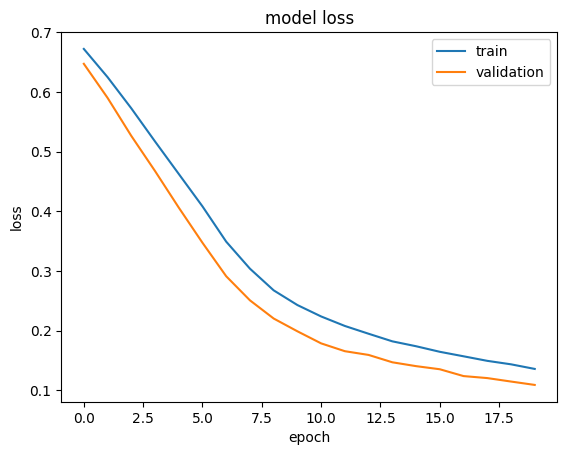

In [ ]:
# Plotting the loss.

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show()

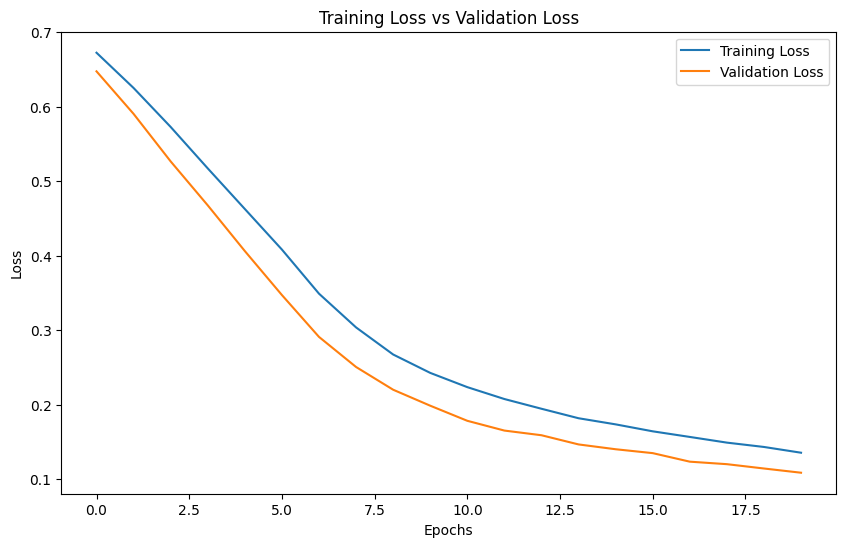

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training Loss vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Task 5: Why the model is over fitting? -- 02 Marks

Give answer over here

**Answer:**

The model is overfitting because:

* it is trained for too many epochs (600)
* the dataset is small
* the model starts memorizing training patterns instead of generalizing



Signs of overfitting:

* training loss keeps decreasing
* validation loss starts increasing after some point

* Apply Early Stopping

In [ ]:
# Defining the early stopping criterion so that the fitting stops a bit early

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss',
                           mode='min',
                           verbose=1,
                           patience=25
                           restore_best_weights=True
                           )

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3275823789.py, line 8)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    mode='min',
    verbose=1,
    patience=25,
    restore_best_weights=True
)

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(units=INPUT_LAYER_NEURON,
                          activation=LAYER_ACTIVATION,
                          input_shape=[input_shape]),
    tf.keras.layers.Dense(units=15, activation=LAYER_ACTIVATION),
    tf.keras.layers.Dense(units=OUTPUT_LAYER_NEURONS,
                          activation=LAST_LAYER_ACTIVATION)
])

model.compile(
    loss=LOSS,
    optimizer=OPT,
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 30)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 15)             │           465 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,441 (5.63 KB)

 Trainable params: 1,441 (5.63 KB)

 Non-trainable params: 0 (0.00 B)

# Task 6: You need to call the model fitting function with **early_stop** -- 02 Marks

In [ ]:
# Calling the fit function with the early stopping
model.fit(#
          #
          #
          #
          #
          )

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=600,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 178ms/step - accuracy: 0.6033 - loss: 0.6926 - val_accuracy: 0.7483 - val_loss: 0.6701
Epoch 2/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8192 - loss: 0.6514 - val_accuracy: 0.8811 - val_loss: 0.6230
Epoch 3/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8568 - loss: 0.6111 - val_accuracy: 0.8811 - val_loss: 0.5784
Epoch 4/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8592 - loss: 0.5696 - val_accuracy: 0.8881 - val_loss: 0.5249
Epoch 5/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8709 - loss: 0.5193 - val_accuracy: 0.8881 - val_loss: 0.4665
Epoch 6/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8779 - loss: 0.4724 - val_accuracy: 0.9021 - val_loss: 0.4118
Epoch 7/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8709 - loss: 0.4247 - val_accuracy: 0.9021 - val_loss: 0.3620
Epoch 8/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8803 - loss: 0.3807 - val_accuracy: 0.9161 -

# Task 7: Plot the new training and validation loss -- 3 Marks

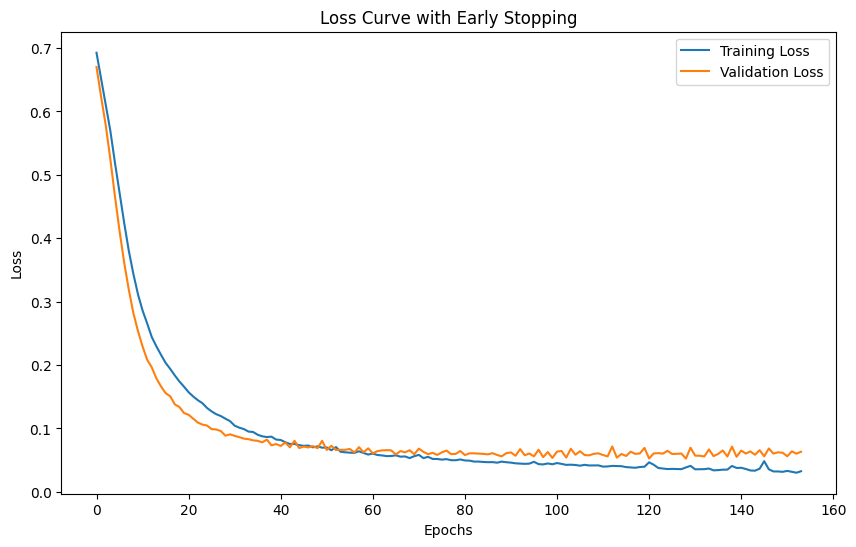

In [ ]:
# Plotting the new model loss with early stopping

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve with Early Stopping')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Task 8: Interpret the difference in the two plots -- 02 Marks

Answer:

In the first plot:

* training loss keeps decreasing
* validation loss starts increasing later
* this shows overfitting

In the second plot:

* training stops earlier
* validation loss does not increase too much
* model generalizes better
* early stopping prevents unnecessary training